In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


In [82]:
df=pd.read_csv("concrete_data.csv")

In [83]:
df

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [84]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [85]:
x1=x.iloc[:,0:1]
x2=x.iloc[:,1:2]
x3=x.iloc[:,2:3]
x4=x.iloc[:,3:4]
x5=x.iloc[:,4:5]
x6=x.iloc[:,5:6]
x7=x.iloc[:,6:7]
x8=x.iloc[:,7:8]

In [86]:
# a .plot against y
def plot_against_y(x,y):
    plt.figure(figsize=(6,6))
    plt.scatter(x,y)

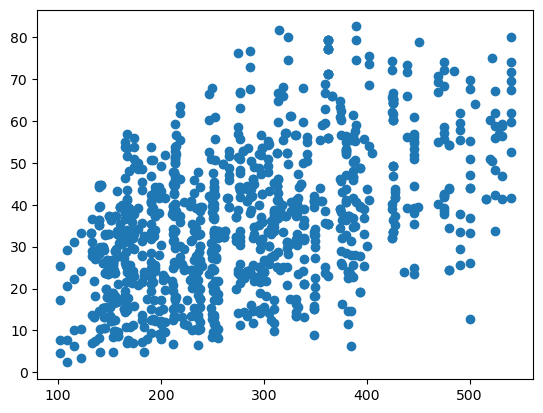

In [87]:
plt.scatter(x1,y)

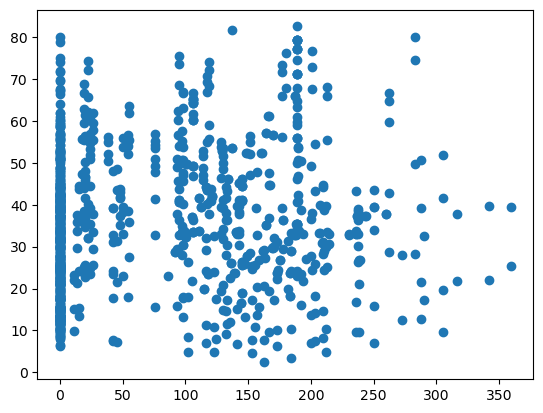

In [88]:
plt.scatter(x2,y)

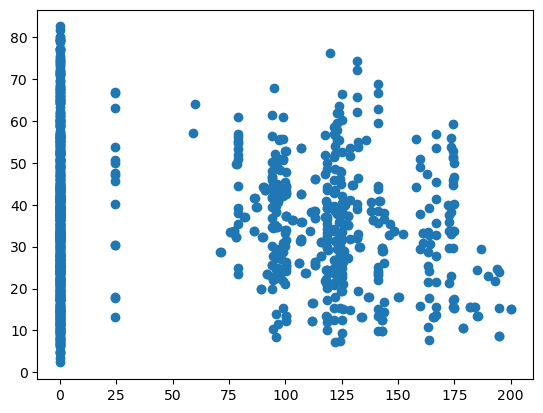

In [89]:
plt.scatter(x3,y)

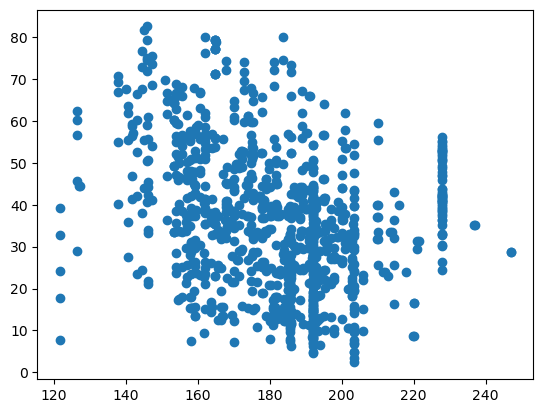

In [90]:
plt.scatter(x4,y)

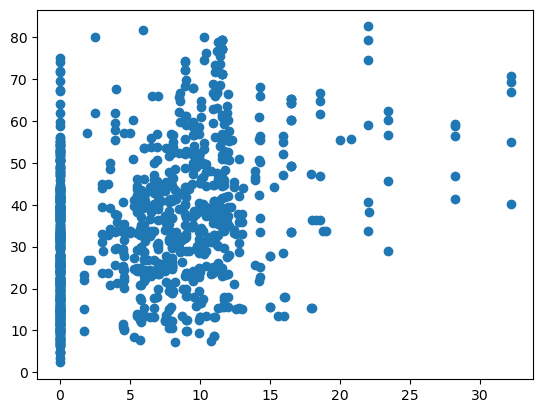

In [91]:
plt.scatter(x5,y)

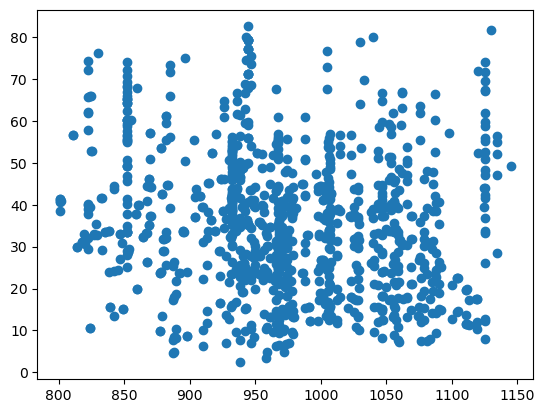

In [92]:
plt.scatter(x6,y)

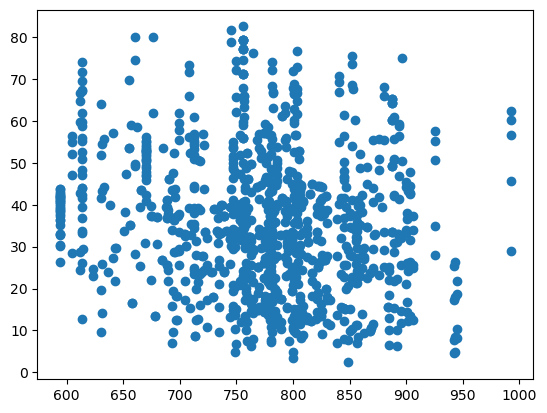

In [93]:
plt.scatter(x7,y)

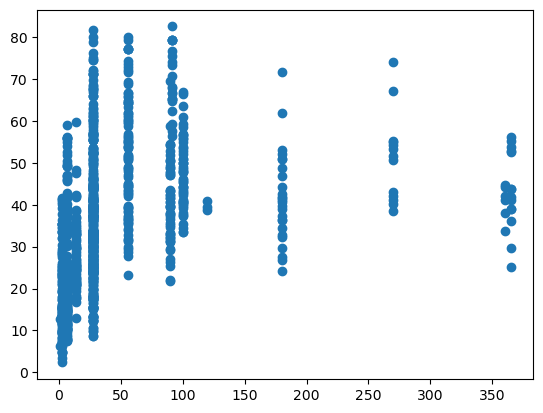

In [94]:
plt.scatter(x8,y)

In [140]:
def model(X,w,b):
    return np.dot(X,w)+b;

In [141]:
# b.Cost function
def cost_function(X,y,w,b):
    m=len(y)
    y_pred=model(X,w,b)
    return (1/(2*m))*np.sum((y-y_pred)**2)

In [125]:

def gradient_descent(X, y, w, b, lr, epochs):
    cost_history = []
    b_history = []
    w_history = []
    m = len(y)
    
    for epoch in range(epochs):
        # Predictions
        y_pred = model(X, w, b)
        
        # Gradients
        dw = (1/m) * np.dot(X.T, (y_pred - y))
        db = (1/m) * np.sum(y_pred - y)
        
        # Update parameters
        w -= lr * dw
        b -= lr * db
        
        # Compute cost and store history
        cost = cost_function(X, y, w, b)
        cost_history.append(cost)
        w_history.append(w.copy())
        b_history.append(b)
    
    return w, b, cost_history, w_history, b_history


In [142]:
X = df[["cement"]].values 
Y = df["concrete_compressive_strength"].values

In [143]:
X = (X - np.mean(X)) / np.std(X)

In [144]:
w=np.zeros(X.shape[1])
b=0

In [145]:
w

array([0.])

In [146]:
lrs = [0.1, 0.01, 0.001, 0.0001, 0.00001] 
epochs = 500

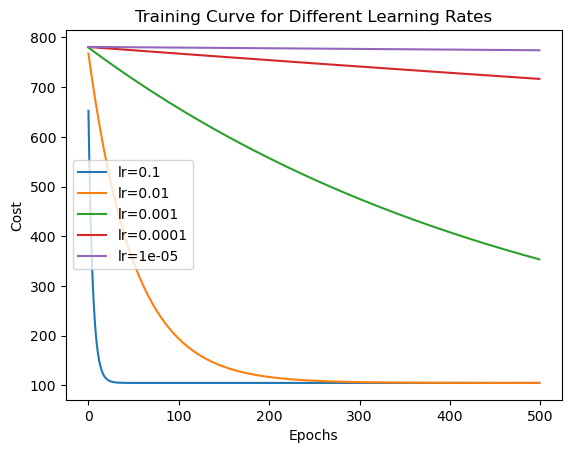

In [154]:
for lr in lrs:
    w_opt, b_opt, cost_hist, w_hist, b_hist = gradient_descent(X, Y, w.copy(), b, lr, epochs)
    plt.plot(cost_hist, label=f"lr={lr}")  # only plot once per learning rate

plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.title("Training Curve for Different Learning Rates")
plt.legend()
plt.show()  # show all curves in one figure






In [77]:
X_test = np.array([[540], [200]]) # Cement values 
X_test = (X_test - np.mean(df["cement"])) / np.std(df["cement"]) # normalize 
y_pred = model(X_test, w_opt, b_opt) 
print("Predictions for test samples:", y_pred)





Predictions for test samples: [0.0001522  0.00042277]
